In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import stim
import numpy as np
import pymatching

from qecsim.surface_code_rotated.circuit import rotated_surface_code

In [3]:
noise = 0.007
distance = 7

c_0_z = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Z", state_init = "0", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_1_z = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Z", state_init = "1", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_p_x = rotated_surface_code(distance = distance, rounds = distance, log_obs = "X", state_init = "+", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_m_x = rotated_surface_code(distance = distance, rounds = distance, log_obs = "X", state_init = "-", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_0_x, rec_pos_log_x = rotated_surface_code(distance = distance, rounds = distance, log_obs = "X", state_init = "0", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_1_x, rec_pos_log_x = rotated_surface_code(distance = distance, rounds = distance, log_obs = "X", state_init = "1", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_p_z, rec_pos_log_z = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Z", state_init = "+", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)
c_m_z, rec_pos_log_z = rotated_surface_code(distance = distance, rounds = distance, log_obs = "Z", state_init = "-", noise_after_clifford_depol = noise, noise_after_reset = noise, noise_depol_data_init = noise, noise_measure_flip = noise)

In [4]:
def building_ptm(circuit_0_z: stim.Circuit, circuit_1_z: stim.Circuit, 
                 circuit_0_x: stim.Circuit, circuit_1_x: stim.Circuit, 
                 circuit_p_x: stim.Circuit, circuit_m_x: stim.Circuit, 
                 circuit_p_z: stim.Circuit, circuit_m_z: stim.Circuit,
                 rec_pos_log_x : list, rec_pos_log_z : list, samples : int = 50) -> np.ndarray:

    """
    Building PTM by building each possible memory circuit and measurement combination
    -> + logical -> Measuring in x/z/y basis
    -> - logical -> Measuring in x/z/y basis
    -> 0 logical -> Measuring in x/z/y basis
    -> 1 logical -> Measuring in x/z/y basis
    -> +i logical -> Measuring in x/z/y basis

    What we do:
        * Determine the noise clean expectation of the measurement
        * Compute the noisy current observable status (xor noiseless initlial state by obs state)
        * Run QEC and check whether the noisy observable should be flipped or not
        * Flip the observable i.e. the clean expectation value
        * Build up PTM out of the expectaition values
     """

    #####################################
    # Builing Diagonal Entries of the PTM
    #####################################

    # Correct nosieless Measurements
    clean_meas_0_z = False
    clean_meas_1_z = True
    clean_meas_p_x = False
    clean_meas_m_x = True

    # Build a graphlike DEM and a matcher
    dem_0_z = circuit_0_z.detector_error_model(decompose_errors=True)
    m_0_z = pymatching.Matching.from_detector_error_model(dem_0_z)
    dem_1_z = circuit_1_z.detector_error_model(decompose_errors=True)
    m_1_z = pymatching.Matching.from_detector_error_model(dem_1_z)
    dem_p_x = circuit_p_x.detector_error_model(decompose_errors=True)
    m_p_x = pymatching.Matching.from_detector_error_model(dem_p_x)
    dem_m_x = circuit_m_x.detector_error_model(decompose_errors=True)
    m_m_x = pymatching.Matching.from_detector_error_model(dem_m_x)

    # Take m shots of detection events
    sampler_0_z = circuit_0_z.compile_detector_sampler()
    dets_0_z, obs_0_z = sampler_0_z.sample(samples, separate_observables=True)
    
    sampler_1_z = circuit_1_z.compile_detector_sampler()
    dets_1_z, obs_1_z = sampler_1_z.sample(samples, separate_observables=True)

    sampler_p_x = circuit_p_x.compile_detector_sampler()
    dets_p_x, obs_p_x = sampler_p_x.sample(samples, separate_observables=True)
    
    sampler_m_x = circuit_m_x.compile_detector_sampler()
    dets_m_x, obs_m_x = sampler_m_x.sample(samples, separate_observables=True)

    # Determine current noisy Operator states (i.e. xor obs from det sample with noiseless Measurement outcome)
    """
    THIS IS TOO MUCH WORK AND CAN BE SIMPLIFIED
    -> Just return freom each circuit the log rec tragets not only for the non determinstic emasurements
    -> Do analogue method than for the off diagonals
    -> This works but is more complicated and results in two methods beeing used in one function which can be mitigated
    """

    noisy_meas_0_z = []
    noisy_meas_1_z = []
    noisy_meas_p_x = []
    noisy_meas_m_x = []

    for curr_shot in range(samples):
        noisy_meas_0_z.append(obs_0_z[curr_shot,0] ^ clean_meas_0_z)
        noisy_meas_1_z.append(obs_1_z[curr_shot,0] ^ clean_meas_1_z)
        noisy_meas_p_x.append(obs_p_x[curr_shot,0] ^ clean_meas_p_x)
        noisy_meas_m_x.append(obs_m_x[curr_shot,0] ^ clean_meas_m_x)

    # Decode all sample round in one Batch decode
    pred_0_z = m_0_z.decode_batch(dets_0_z)
    pred_1_z = m_1_z.decode_batch(dets_1_z)
    pred_p_x = m_p_x.decode_batch(dets_p_x)
    pred_m_x = m_m_x.decode_batch(dets_m_x)

    # XOR flip with noiseless Measurement
    # -> Taking first entry for first logical observable
    final_meas_0_z = []
    final_meas_1_z = []
    final_meas_p_x = []
    final_meas_m_x = []

    for curr_shot in range(samples):
        final_meas_0_z.append( 1 - 2 * (pred_0_z[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_0_z[curr_shot])))
        final_meas_1_z.append( 1 - 2 * (pred_1_z[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_1_z[curr_shot])))
        final_meas_p_x.append( 1 - 2 * (pred_p_x[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_p_x[curr_shot])))
        final_meas_m_x.append( 1 - 2 * (pred_m_x[curr_shot,0].astype(np.int8) ^ np.int8(noisy_meas_m_x[curr_shot])))

    # Take the Average of each of them
    mu_z_pz = np.average(final_meas_0_z)
    mu_z_mz = np.average(final_meas_1_z)
    mu_x_px = np.average(final_meas_p_x)
    mu_x_mx = np.average(final_meas_m_x)

    # Calc PTM entries
    r_zz = 1/2 * (mu_z_pz - mu_z_mz)
    r_xx = 1/2 * (mu_x_px - mu_x_mx)

    ######################################
    # Building Off-Diagonals of the Matrix
    ######################################

    """
    For the Off-Diagonals we can't directly use the DEM as we need the raw measurements to infer what logical state we have

    -> We use compile sampler to infer the logical state
    -> Convert into a dem to run the matching
    """

    # Build the normal measurement smaples and sample n shots
    smpl_0_x = circuit_0_x.compile_sampler()
    rstls_smpls_0_x = smpl_0_x.sample(shots = samples)
    smpl_1_x = circuit_1_x.compile_sampler()
    rstls_smpls_1_x = smpl_1_x.sample(shots = samples)
    smpl_p_z = circuit_p_z.compile_sampler()
    rstls_smpls_p_z = smpl_p_z.sample(shots = samples)
    smpl_m_z = circuit_m_z.compile_sampler()
    rstls_smpls_m_z = smpl_m_z.sample(shots = samples)

    # Getting the individual logical states after measurement
    log_state_0_x = []
    log_state_1_x = []
    log_state_p_z = []
    log_state_m_z = []

    for curr_shot in range(samples):

        measurement_res_0_x = -99
        measurement_res_1_x = -99
        measurement_res_p_z = -99
        measurement_res_m_z = -99

        # Do the first loop for all x basis measurements
        for current_tar_rec in rec_pos_log_x:
            
            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_0_x == -99:
                measurement_res_0_x = rstls_smpls_0_x[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_0_x ^= rstls_smpls_0_x[curr_shot, current_tar_rec]

            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_1_x == -99:
                measurement_res_1_x = rstls_smpls_1_x[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_1_x ^= rstls_smpls_1_x[curr_shot, current_tar_rec]

        # Do the same for z
        for current_tar_rec in rec_pos_log_z:
            
            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_p_z == -99:
                measurement_res_p_z = rstls_smpls_p_z[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_p_z ^= rstls_smpls_p_z[curr_shot, current_tar_rec]

            # If this is the first, set the resutl to this measurement outcome
            if measurement_res_m_z == -99:
                measurement_res_m_z = rstls_smpls_m_z[curr_shot, current_tar_rec]

            # else xor measurement to the already present ones
            else:
                measurement_res_m_z ^= rstls_smpls_m_z[curr_shot, current_tar_rec]

        # Appending the current measurements to the list
        log_state_0_x.append(measurement_res_0_x)
        log_state_1_x.append(measurement_res_1_x)
        log_state_p_z.append(measurement_res_p_z)
        log_state_m_z.append(measurement_res_m_z)

    # Build a graphlike DEM and a matcher
    dem_0_x = circuit_0_x.detector_error_model(decompose_errors=True)
    m_0_x = pymatching.Matching.from_detector_error_model(dem_0_x)
    dem_1_x = circuit_1_x.detector_error_model(decompose_errors=True)
    m_1_x = pymatching.Matching.from_detector_error_model(dem_1_x)
    dem_p_z = circuit_p_z.detector_error_model(decompose_errors=True)
    m_p_z = pymatching.Matching.from_detector_error_model(dem_p_z)
    dem_m_z = circuit_m_z.detector_error_model(decompose_errors=True)
    m_m_z = pymatching.Matching.from_detector_error_model(dem_m_z)

    # Converting the measurement sample into DEM sample and continue as usual with decoding
    cvrtr_0_x = circuit_0_x.compile_m2d_converter()
    dets_ops_0_x = cvrtr_0_x.convert(measurements = rstls_smpls_0_x, append_observables=True)
    num_dets = dem_0_x.num_detectors
    num_obs  = dem_0_x.num_observables
    dets_0_x = dets_ops_0_x[:, :num_dets]
    obs_0_x  = dets_ops_0_x[:, num_dets:num_dets+num_obs]


    cvrtr_1_x = circuit_1_x.compile_m2d_converter()
    dets_ops_1_x = cvrtr_1_x.convert(measurements = rstls_smpls_1_x, append_observables=True)
    num_dets = dem_1_x.num_detectors
    num_obs  = dem_1_x.num_observables
    dets_1_x = dets_ops_1_x[:, :num_dets]
    obs_1_x  = dets_ops_1_x[:, num_dets:num_dets+num_obs]


    cvrtr_p_z = circuit_p_z.compile_m2d_converter()
    dets_ops_p_z = cvrtr_p_z.convert(measurements = rstls_smpls_p_z, append_observables=True)
    num_dets = dem_p_z.num_detectors
    num_obs  = dem_p_z.num_observables
    dets_p_z = dets_ops_p_z[:, :num_dets]
    obs_p_z  = dets_ops_p_z[:, num_dets:num_dets+num_obs]


    cvrtr_m_z = circuit_m_z.compile_m2d_converter()
    dets_ops_m_z = cvrtr_m_z.convert(measurements = rstls_smpls_m_z, append_observables=True)
    num_dets = dem_m_z.num_detectors
    num_obs  = dem_m_z.num_observables
    dets_m_z = dets_ops_m_z[:, :num_dets]
    obs_m_z  = dets_ops_m_z[:, num_dets:num_dets+num_obs]

    # Decode all sample round in one Batch decode
    pred_0_x = m_0_x.decode_batch(dets_0_x)
    pred_1_x = m_1_x.decode_batch(dets_1_x)
    pred_p_z = m_p_z.decode_batch(dets_p_z)
    pred_m_z = m_m_z.decode_batch(dets_m_z)

    # Init final state List after EC
    final_meas_0_x : list = []
    final_meas_1_x : list = []
    final_meas_p_z : list = []
    final_meas_m_z : list = []

    # XOR flip with noiseless Measurement (looping over all samples and compoaring to the current logical outcome in the list)
    # -> Taking first entry for first logical observable
    for current_sample in range(samples):
        curr_meas_0_x = 1 - 2 * (pred_0_x[current_sample,0].astype(np.int8) ^ np.int8(log_state_0_x[current_sample]))
        curr_meas_1_x = 1 - 2 * (pred_1_x[current_sample,0].astype(np.int8) ^ np.int8(log_state_1_x[current_sample]))
        curr_meas_p_z = 1 - 2 * (pred_p_z[current_sample,0].astype(np.int8) ^ np.int8(log_state_p_z[current_sample]))
        curr_meas_m_z = 1 - 2 * (pred_m_z[current_sample,0].astype(np.int8) ^ np.int8(log_state_m_z[current_sample]))

        #Adding final XORed measurement into the list
        final_meas_0_x.append(curr_meas_0_x)
        final_meas_1_x.append(curr_meas_1_x)
        final_meas_p_z.append(curr_meas_p_z)
        final_meas_m_z.append(curr_meas_m_z)

    # Take the Average of each of them
    mu_x_pz = np.average(final_meas_0_x)
    mu_x_mz = np.average(final_meas_1_x)
    mu_z_px = np.average(final_meas_p_z)
    mu_z_mx = np.average(final_meas_m_z)

    # Calc PTM entries
    r_zx = 1/2 * (mu_z_px - mu_z_mx)
    r_xz = 1/2 * (mu_x_pz - mu_x_mz)

    # Create PTM Matrix
    ptm = [
        [r_xx, 0.0, r_xz], 
        [0.0, 0.0 , 0.0], 
        [r_zx, 0.0 , r_zz]]

    return(np.array(ptm))

In [5]:
building_ptm(circuit_0_x = c_0_x, circuit_1_x = c_1_x, circuit_0_z = c_0_z, circuit_1_z = c_1_z,
            circuit_p_x = c_p_x, circuit_m_x = c_m_x, circuit_p_z = c_p_z, circuit_m_z = c_m_z, rec_pos_log_x = rec_pos_log_x, 
            rec_pos_log_z = rec_pos_log_z, samples = 10_000)

array([[0.931 , 0.    , 0.0021],
       [0.    , 0.    , 0.    ],
       [0.005 , 0.    , 0.9373]])

['Z17', 'Z32', 'Z46', 'Z61', 'Z75', 'Z90', 'Y3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9']


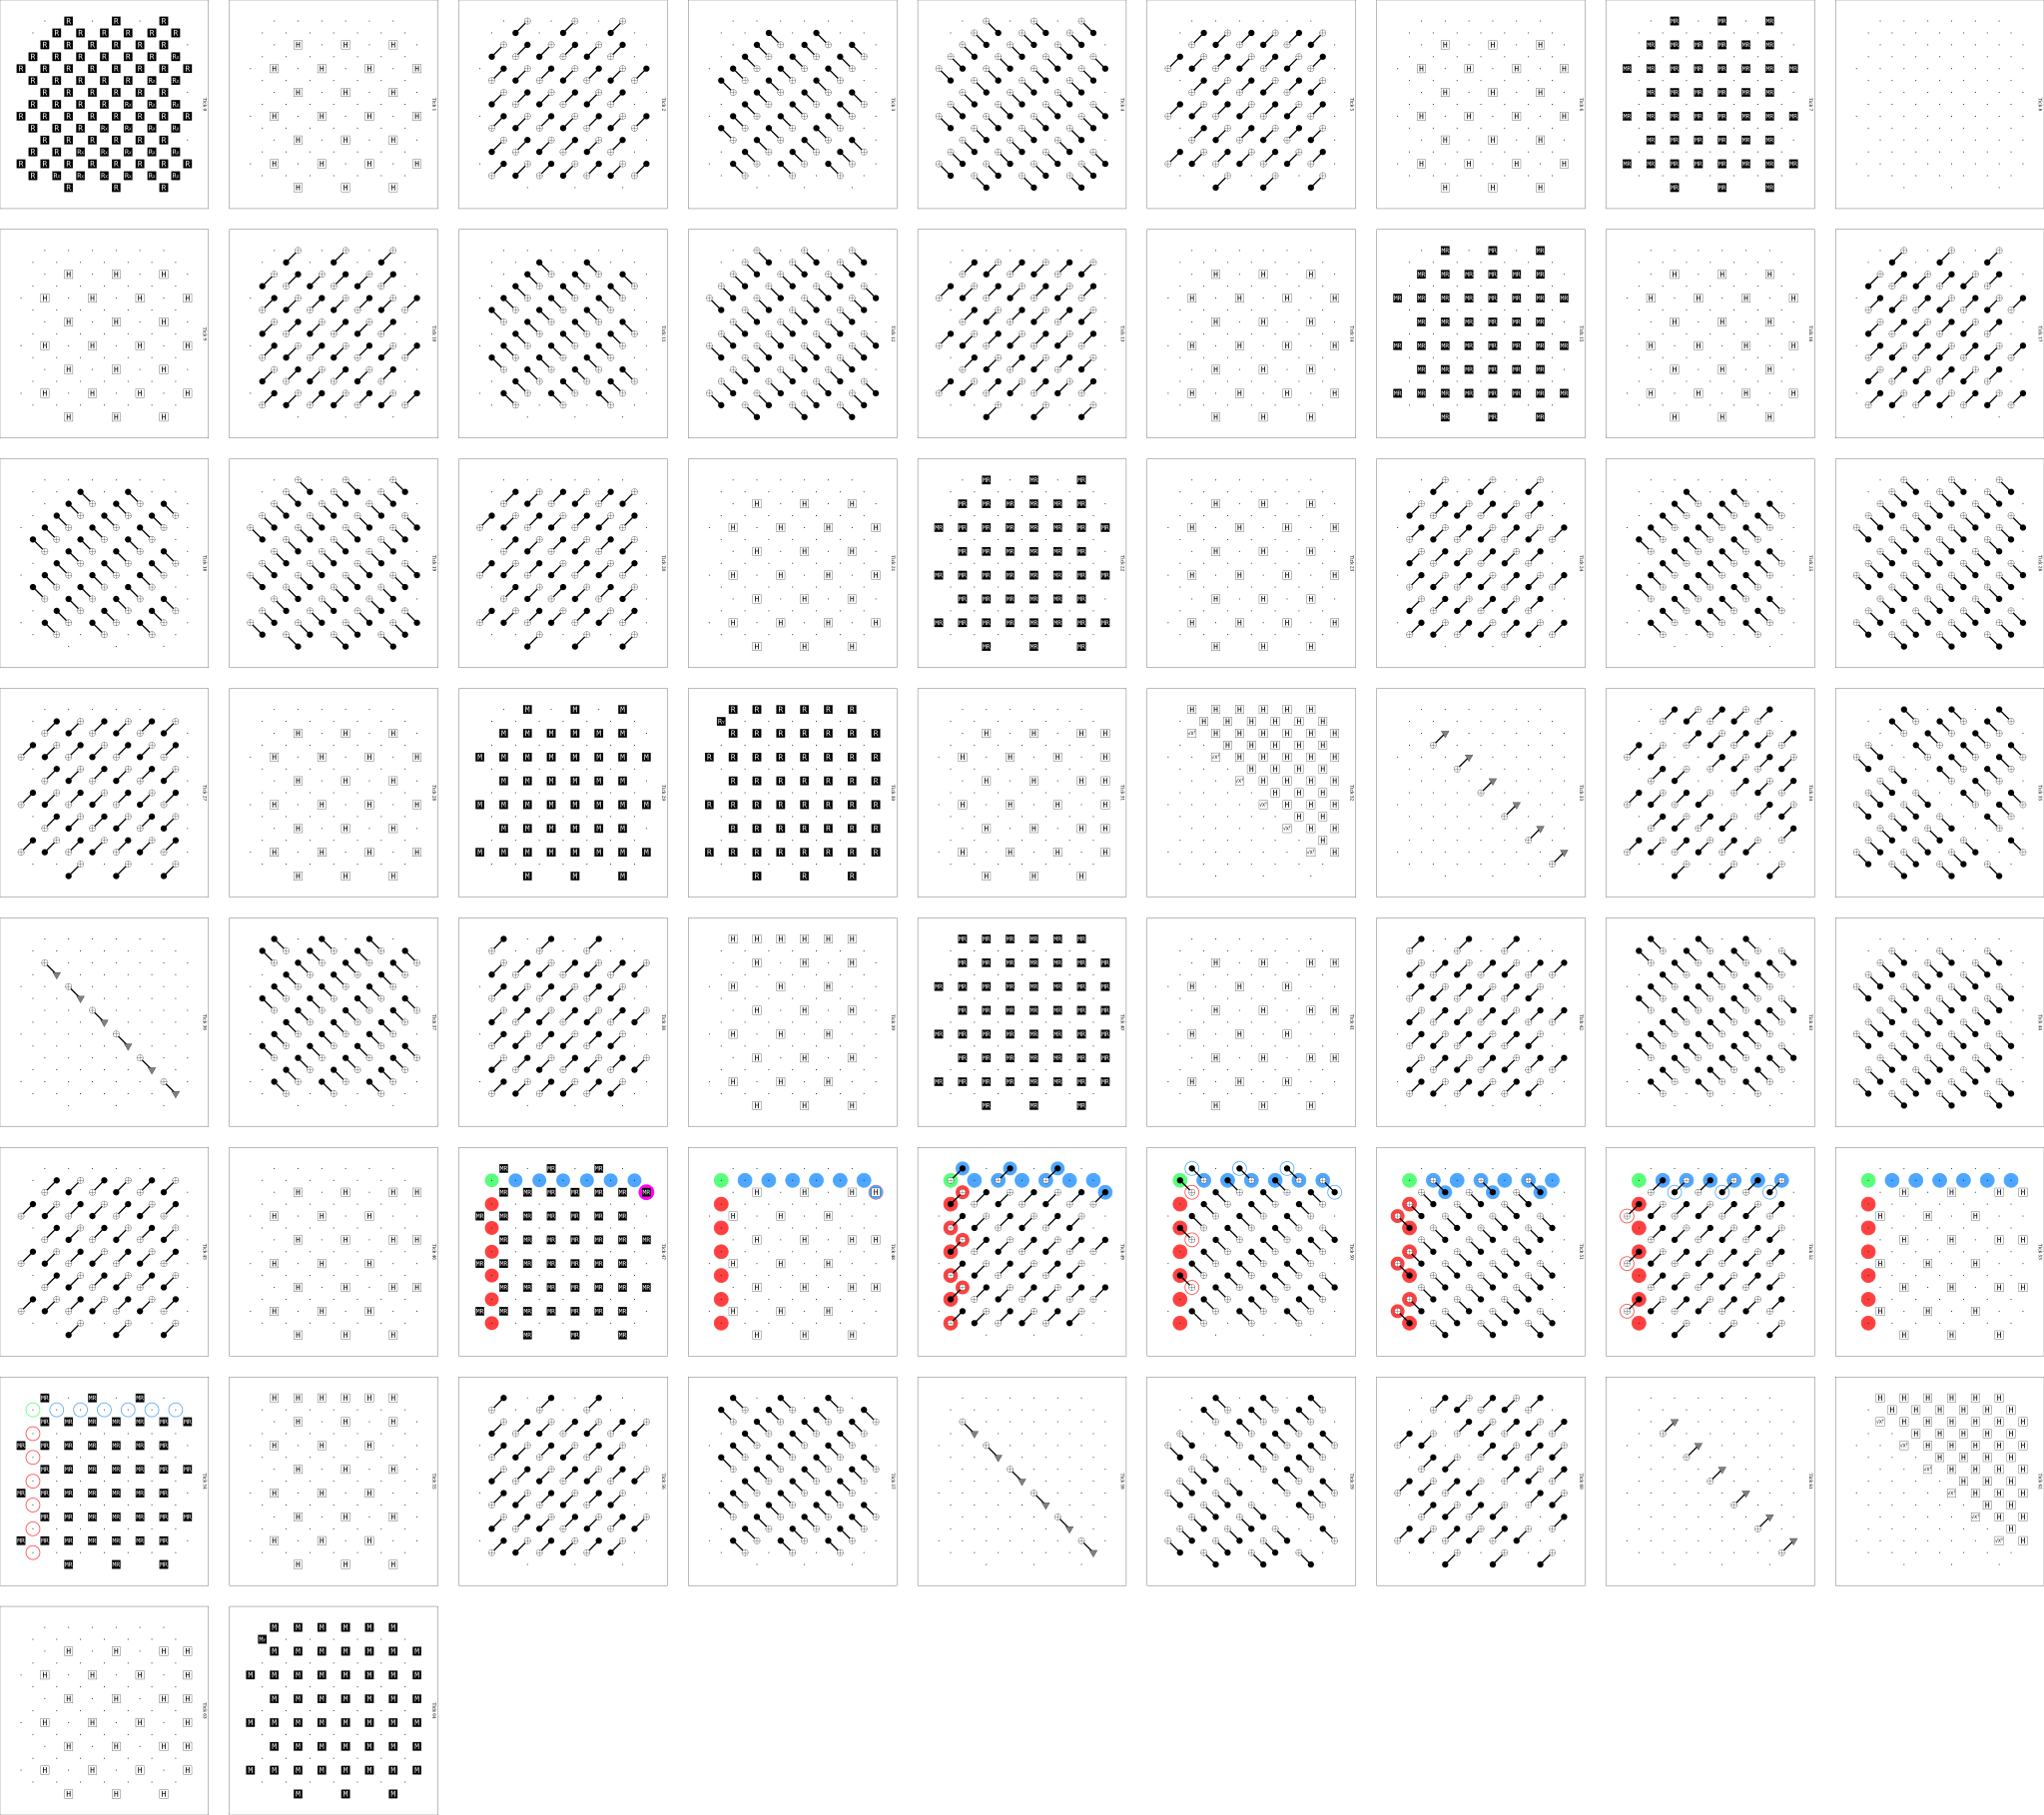

In [37]:
rotated_surface_code(distance = 7, rounds = 7, log_obs = "Y", state_init = "+i").diagram("detslice-with-ops", filter_coords = ["L0"])

In [7]:
tt = stim.Circuit("""
QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 1) 1
QUBIT_COORDS(0, 2) 2
QUBIT_COORDS(0, 3) 3
QUBIT_COORDS(0, 4) 4
QUBIT_COORDS(1, 0) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(1, 2) 7
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(1, 4) 9
QUBIT_COORDS(2, 0) 10
QUBIT_COORDS(2, 1) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(2, 3) 13
QUBIT_COORDS(2, 4) 14
QUBIT_COORDS(3, 0) 15
QUBIT_COORDS(3, 1) 16
QUBIT_COORDS(3, 2) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(3, 4) 19
QUBIT_COORDS(4, 0) 20
QUBIT_COORDS(4, 1) 21
QUBIT_COORDS(4, 2) 22
QUBIT_COORDS(4, 3) 23
QUBIT_COORDS(4, 4) 24
QUBIT_COORDS(-0.5, 1.5) 25
QUBIT_COORDS(-0.5, 3.5) 26
QUBIT_COORDS(0.5, -0.5) 27
QUBIT_COORDS(0.5, 0.5) 28
QUBIT_COORDS(0.5, 1.5) 29
QUBIT_COORDS(0.5, 2.5) 30
QUBIT_COORDS(0.5, 3.5) 31
QUBIT_COORDS(1.5, -0.5) 32
QUBIT_COORDS(1.5, 0.5) 33
QUBIT_COORDS(1.5, 1.5) 34
QUBIT_COORDS(1.5, 2.5) 35
QUBIT_COORDS(1.5, 3.5) 36
QUBIT_COORDS(1.5, 4.5) 37
QUBIT_COORDS(2.5, -0.5) 38
QUBIT_COORDS(2.5, 0.5) 39
QUBIT_COORDS(2.5, 1.5) 40
QUBIT_COORDS(2.5, 2.5) 41
QUBIT_COORDS(2.5, 3.5) 42
QUBIT_COORDS(3.5, -0.5) 43
QUBIT_COORDS(3.5, 0.5) 44
QUBIT_COORDS(3.5, 1.5) 45
QUBIT_COORDS(3.5, 2.5) 46
QUBIT_COORDS(3.5, 3.5) 47
QUBIT_COORDS(3.5, 4.5) 48
QUBIT_COORDS(4.5, 0.5) 49
QUBIT_COORDS(4.5, 1.5) 50
QUBIT_COORDS(4.5, 2.5) 51
QUBIT_COORDS(4.5, 3.5) 52
R 47 45 43 41 39 36 34 32 30 28 26 25 20 16 15 12 11 10 8 7 6 5 4 3 2 1 24 23 22 21 19 18 17 14 13 9 52 50 48 46 44 42 40 37 35 33 31 29
TICK
H 2 4 6 8 9 12 13 16 17 19 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
CZ 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 22 24
TICK
CZ 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 1 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 32 43 50 52
TICK
CZ 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 6 8 10 12 14 16 18 20 22 24 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
M 47 45 43 41 39 36 34 32 30 28 26 25 52 50 48 46 44 42 40 37 35 33 31 29
DETECTOR(-0.5, 1.5, 0) rec[-13]
DETECTOR(-0.5, 3.5, 0) rec[-14]
DETECTOR(0.5, 0.5, 0) rec[-15]
DETECTOR(0.5, 2.5, 0) rec[-16]
DETECTOR(1.5, -0.5, 0) rec[-17]
DETECTOR(1.5, 1.5, 0) rec[-18]
DETECTOR(1.5, 4.5, 0) rec[-5]
DETECTOR(2.5, 0.5, 0) rec[-20]
DETECTOR(2.5, 3.5, 0) rec[-7]
DETECTOR(3.5, -0.5, 0) rec[-22]
DETECTOR(3.5, 2.5, 0) rec[-9]
DETECTOR(3.5, 4.5, 0) rec[-10]
DETECTOR(4.5, 1.5, 0) rec[-11]
DETECTOR(4.5, 3.5, 0) rec[-12]
SHIFT_COORDS(0, 0, 1)
TICK
REPEAT 2 {
    R 47 45 43 41 39 36 34 32 30 28 26 25 52 50 48 46 44 42 40 37 35 33 31 29
    TICK
    H 2 4 6 8 12 14 16 18 22 24 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
    TICK
    CZ 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
    TICK
    H 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 21 22 23 24
    TICK
    CZ 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
    TICK
    CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
    TICK
    H 1 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 32 43 50 52
    TICK
    CZ 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
    TICK
    H 6 8 10 12 14 16 18 20 22 24 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
    TICK
    M 47 45 43 41 39 36 34 32 30 28 26 25 52 50 48 46 44 42 40 37 35 33 31 29
    DETECTOR(-0.5, 1.5, 0) rec[-37] rec[-13]
    DETECTOR(-0.5, 3.5, 0) rec[-38] rec[-14]
    DETECTOR(0.5, 0.5, 0) rec[-39] rec[-15]
    DETECTOR(0.5, 1.5, 0) rec[-25] rec[-1]
    DETECTOR(0.5, 2.5, 0) rec[-40] rec[-16]
    DETECTOR(0.5, 3.5, 0) rec[-26] rec[-2]
    DETECTOR(1.5, -0.5, 0) rec[-41] rec[-17]
    DETECTOR(1.5, 0.5, 0) rec[-27] rec[-3]
    DETECTOR(1.5, 1.5, 0) rec[-42] rec[-18]
    DETECTOR(1.5, 2.5, 0) rec[-28] rec[-4]
    DETECTOR(1.5, 3.5, 0) rec[-43] rec[-19]
    DETECTOR(1.5, 4.5, 0) rec[-29] rec[-5]
    DETECTOR(2.5, 0.5, 0) rec[-44] rec[-20]
    DETECTOR(2.5, 1.5, 0) rec[-30] rec[-6]
    DETECTOR(2.5, 2.5, 0) rec[-45] rec[-21]
    DETECTOR(2.5, 3.5, 0) rec[-31] rec[-7]
    DETECTOR(3.5, -0.5, 0) rec[-46] rec[-22]
    DETECTOR(3.5, 0.5, 0) rec[-32] rec[-8]
    DETECTOR(3.5, 1.5, 0) rec[-47] rec[-23]
    DETECTOR(3.5, 2.5, 0) rec[-33] rec[-9]
    DETECTOR(3.5, 3.5, 0) rec[-48] rec[-24]
    DETECTOR(3.5, 4.5, 0) rec[-34] rec[-10]
    DETECTOR(4.5, 1.5, 0) rec[-35] rec[-11]
    DETECTOR(4.5, 3.5, 0) rec[-36] rec[-12]
    SHIFT_COORDS(0, 0, 1)
    TICK
}
R 47 45 43 41 39 38 36 34 32 30 28 27 26 25 0 52 51 50 49 48 46 44 42 40 37 35 33 31 29
TICK
C_ZYX 28 34 41 47
H 6 8 10 12 14 16 18 22 24 25 26 27 29 30 31 32 35 36 37 39 42 43 44 45 48 50
SQRT_X 0 33 40 46 52
TICK
CZ 6 33 12 40 18 46 24 52
TICK
CZ 1 25 3 26 5 32 6 29 7 30 8 31 10 38 11 39 12 35 13 36 14 37 15 43 16 44 17 45 18 42 21 49 22 50 23 51 24 48
TICK
C_XYZ 6 12 18 24
C_ZYX 33 40 46 52
H 1 3 5 7 8 9 10 11 13 14 15 16 17 19 21 22 23 38 49 51
TICK
CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
C_ZYX 24
H 1 3 4 5 10 11 14 15 16 17 20 21 22 23 25 26 32 33 37 39 40 43 44 45 46 48 50 52
SQRT_X 6 12 18
TICK
CZ 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
TICK
H 0 2 5 6 7 8 9 10 11 12 13 15 16 17 18 19 20 21 22 23
TICK
CZ 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
TICK
H 0 2 4 9 19 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
M 52 51 50 49 47 45 41 39 36 34 30 28 26 25 48 46 44 43 42 40 38 37 35 33 32 31 29 27
DETECTOR(-0.5, 1.5, 0) rec[-41] rec[-15]
DETECTOR(-0.5, 3.5, 0) rec[-42] rec[-16]
DETECTOR(0.5, 0.5, 0) rec[-43] rec[-17] rec[-1]
DETECTOR(0.5, 1.5, 0) rec[-29] rec[-2]
DETECTOR(0.5, 2.5, 0) rec[-44] rec[-18]
DETECTOR(0.5, 3.5, 0) rec[-30] rec[-3]
DETECTOR(1.5, -0.5, 0) rec[-45] rec[-4]
DETECTOR(1.5, 0.5, 0) rec[-31] rec[-21]
DETECTOR(1.5, 1.5, 0) rec[-46] rec[-19] rec[-5]
DETECTOR(1.5, 2.5, 0) rec[-32] rec[-6]
DETECTOR(1.5, 3.5, 0) rec[-47] rec[-20]
DETECTOR(1.5, 4.5, 0) rec[-33] rec[-7]
DETECTOR(2.5, 0.5, 0) rec[-48] rec[-8]
DETECTOR(2.5, 1.5, 0) rec[-34] rec[-23]
DETECTOR(2.5, 2.5, 0) rec[-49] rec[-22] rec[-9]
DETECTOR(2.5, 3.5, 0) rec[-35] rec[-10]
DETECTOR(3.5, -0.5, 0) rec[-50] rec[-11]
DETECTOR(3.5, 0.5, 0) rec[-36] rec[-25]
DETECTOR(3.5, 1.5, 0) rec[-51] rec[-12]
DETECTOR(3.5, 2.5, 0) rec[-37] rec[-27]
DETECTOR(3.5, 3.5, 0) rec[-52] rec[-24] rec[-13]
DETECTOR(3.5, 4.5, 0) rec[-38] rec[-14]
DETECTOR(4.5, 1.5, 0) rec[-39] rec[-26]
DETECTOR(4.5, 3.5, 0) rec[-40] rec[-28]
OBSERVABLE_INCLUDE(0) rec[-28] rec[-27] rec[-26] rec[-25] rec[-23] rec[-21] rec[-14] rec[-10] rec[-7] rec[-6] rec[-3] rec[-2]
SHIFT_COORDS(0, 0, 1)
TICK
R 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
TICK
H 25 26 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
TICK
CZ 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 22 45 24 47
TICK
CZ 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
TICK
H 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 23 25 26
TICK
CZ 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
TICK
H 0 2 4 6 8 10 12 14 16 18 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
TICK
M 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
DETECTOR(-0.5, 1.5, 0) rec[-39] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-40] rec[-11]
DETECTOR(0.5, -0.5, 0) rec[-25] rec[-24]
DETECTOR(0.5, 0.5, 0) rec[-41] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-26] rec[-23]
DETECTOR(0.5, 2.5, 0) rec[-42] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-27] rec[-22]
DETECTOR(1.5, 0.5, 0) rec[-29] rec[-28] rec[-21]
DETECTOR(1.5, 1.5, 0) rec[-43] rec[-8]
DETECTOR(1.5, 2.5, 0) rec[-30] rec[-20]
DETECTOR(1.5, 3.5, 0) rec[-44] rec[-7]
DETECTOR(1.5, 4.5, 0) rec[-31] rec[-19]
DETECTOR(2.5, -0.5, 0) rec[-32] rec[-18]
DETECTOR(2.5, 0.5, 0) rec[-45] rec[-6]
DETECTOR(2.5, 1.5, 0) rec[-33] rec[-17]
DETECTOR(2.5, 2.5, 0) rec[-46] rec[-5]
DETECTOR(2.5, 3.5, 0) rec[-34] rec[-16]
DETECTOR(3.5, 0.5, 0) rec[-36] rec[-35] rec[-15]
DETECTOR(3.5, 1.5, 0) rec[-50] rec[-47] rec[-4]
DETECTOR(3.5, 2.5, 0) rec[-37] rec[-14]
DETECTOR(3.5, 3.5, 0) rec[-52] rec[-48] rec[-3]
DETECTOR(3.5, 4.5, 0) rec[-38] rec[-13]
DETECTOR(4.5, 0.5, 0) rec[-49] rec[-2]
DETECTOR(4.5, 2.5, 0) rec[-51] rec[-1]
SHIFT_COORDS(0, 0, 1)
TICK
REPEAT 4 {
    R 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
    TICK
    H 6 8 10 12 14 16 18 20 22 24 25 26 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
    TICK
    CZ 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
    TICK
    H 1 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
    TICK
    CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 22 45 24 47
    TICK
    CZ 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
    TICK
    H 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 23 25 26
    TICK
    CZ 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
    TICK
    H 0 2 4 6 8 10 12 14 16 18 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
    TICK
    M 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
    DETECTOR(-0.5, 1.5, 0) rec[-36] rec[-12]
    DETECTOR(-0.5, 3.5, 0) rec[-35] rec[-11]
    DETECTOR(0.5, -0.5, 0) rec[-48] rec[-24]
    DETECTOR(0.5, 0.5, 0) rec[-34] rec[-10]
    DETECTOR(0.5, 1.5, 0) rec[-47] rec[-23]
    DETECTOR(0.5, 2.5, 0) rec[-33] rec[-9]
    DETECTOR(0.5, 3.5, 0) rec[-46] rec[-22]
    DETECTOR(1.5, 0.5, 0) rec[-45] rec[-21]
    DETECTOR(1.5, 1.5, 0) rec[-32] rec[-8]
    DETECTOR(1.5, 2.5, 0) rec[-44] rec[-20]
    DETECTOR(1.5, 3.5, 0) rec[-31] rec[-7]
    DETECTOR(1.5, 4.5, 0) rec[-43] rec[-19]
    DETECTOR(2.5, -0.5, 0) rec[-42] rec[-18]
    DETECTOR(2.5, 0.5, 0) rec[-30] rec[-6]
    DETECTOR(2.5, 1.5, 0) rec[-41] rec[-17]
    DETECTOR(2.5, 2.5, 0) rec[-29] rec[-5]
    DETECTOR(2.5, 3.5, 0) rec[-40] rec[-16]
    DETECTOR(3.5, 0.5, 0) rec[-39] rec[-15]
    DETECTOR(3.5, 1.5, 0) rec[-28] rec[-4]
    DETECTOR(3.5, 2.5, 0) rec[-38] rec[-14]
    DETECTOR(3.5, 3.5, 0) rec[-27] rec[-3]
    DETECTOR(3.5, 4.5, 0) rec[-37] rec[-13]
    DETECTOR(4.5, 0.5, 0) rec[-26] rec[-2]
    DETECTOR(4.5, 2.5, 0) rec[-25] rec[-1]
    SHIFT_COORDS(0, 0, 1)
    TICK
}
R 27 29 31 32 33 35 37 38 40 42 43 44 46 48 25 26 28 30 34 36 39 41 45 47 49 50 51 52
TICK
H 0 2 4 6 8 10 12 14 16 18 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
TICK
CZ 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
TICK
H 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 23
TICK
CZ 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
TICK
H 5 10 11 15 16 17 20 21 22 23 27 33 38 39 40 44 45 46 49 51
SQRT_X 0 6 12 18 24
TICK
CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
C_XYZ 28 33 34 40 41 46 47 52
C_ZYX 6 12 18 24
H 1 3 5 7 8 10 11 13 14 15 16 17 20 21 22 23
TICK
CZ 1 25 3 26 5 32 6 29 7 30 8 31 10 38 11 39 12 35 13 36 14 37 15 43 16 44 17 45 18 42 21 49 22 50 23 51 24 48
TICK
CZ 6 33 12 40 18 46 24 52
TICK
H 25 26 29 30 31 32 35 36 37 39 42 43 44 45 48 50
SQRT_X 33 40 46 52
TICK
M 29 31 33 35 37 40 42 44 46 48 49 50 51 52 0 25 26 27 28 30 32 34 36 38 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-41] rec[-14]
DETECTOR(-0.5, 3.5, 0) rec[-40] rec[-13]
DETECTOR(0.5, -0.5, 0) rec[-53] rec[-12]
DETECTOR(0.5, 0.5, 0) rec[-39] rec[-27] rec[-11]
DETECTOR(0.5, 1.5, 0) rec[-52] rec[-29]
DETECTOR(0.5, 2.5, 0) rec[-38] rec[-10]
DETECTOR(0.5, 3.5, 0) rec[-51] rec[-28]
DETECTOR(1.5, 0.5, 0) rec[-50] rec[-9]
DETECTOR(1.5, 1.5, 0) rec[-37] rec[-24] rec[-8]
DETECTOR(1.5, 2.5, 0) rec[-49] rec[-26]
DETECTOR(1.5, 3.5, 0) rec[-36] rec[-7]
DETECTOR(1.5, 4.5, 0) rec[-48] rec[-25]
DETECTOR(2.5, -0.5, 0) rec[-47] rec[-6]
DETECTOR(2.5, 0.5, 0) rec[-35] rec[-22]
DETECTOR(2.5, 1.5, 0) rec[-46] rec[-5]
DETECTOR(2.5, 2.5, 0) rec[-34] rec[-21] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-45] rec[-23]
DETECTOR(3.5, 0.5, 0) rec[-44] rec[-3]
DETECTOR(3.5, 1.5, 0) rec[-33] rec[-18]
DETECTOR(3.5, 2.5, 0) rec[-43] rec[-2]
DETECTOR(3.5, 3.5, 0) rec[-32] rec[-16] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-42] rec[-20]
DETECTOR(4.5, 0.5, 0) rec[-31] rec[-19]
DETECTOR(4.5, 2.5, 0) rec[-30] rec[-17]
OBSERVABLE_INCLUDE(0) rec[-29] rec[-28] rec[-27] rec[-26] rec[-25] rec[-24] rec[-23] rec[-22] rec[-21] rec[-20] rec[-19] rec[-18] rec[-17] rec[-16] rec[-15]
SHIFT_COORDS(0, 0, 1)
TICK
R 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
TICK
H 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 49 50 51 52
SQRT_X 0
TICK
CZ 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
CZ 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26
TICK
CZ 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 2 4 9 19 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
M 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-38] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-37] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-51] rec[-39] rec[-36] rec[-35] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-53] rec[-24]
DETECTOR(0.5, 2.5, 0) rec[-34] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-52] rec[-23]
DETECTOR(1.5, -0.5, 0) rec[-33] rec[-30] rec[-8]
DETECTOR(1.5, 0.5, 0) rec[-51] rec[-22]
DETECTOR(1.5, 1.5, 0) rec[-51] rec[-48] rec[-32] rec[-7]
DETECTOR(1.5, 2.5, 0) rec[-50] rec[-21]
DETECTOR(1.5, 3.5, 0) rec[-31] rec[-6]
DETECTOR(1.5, 4.5, 0) rec[-49] rec[-20]
DETECTOR(2.5, 0.5, 0) rec[-29] rec[-5]
DETECTOR(2.5, 1.5, 0) rec[-48] rec[-19]
DETECTOR(2.5, 2.5, 0) rec[-48] rec[-45] rec[-28] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-47] rec[-18]
DETECTOR(3.5, -0.5, 0) rec[-27] rec[-3]
DETECTOR(3.5, 0.5, 0) rec[-46] rec[-17]
DETECTOR(3.5, 1.5, 0) rec[-26] rec[-2]
DETECTOR(3.5, 2.5, 0) rec[-45] rec[-16]
DETECTOR(3.5, 3.5, 0) rec[-45] rec[-40] rec[-25] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-44] rec[-15]
DETECTOR(4.5, 1.5, 0) rec[-43] rec[-42] rec[-14]
DETECTOR(4.5, 3.5, 0) rec[-41] rec[-40] rec[-13]
SHIFT_COORDS(0, 0, 1)
TICK
R 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
TICK
H 20 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
CZ 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
CZ 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26
TICK
CZ 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 2 4 9 19 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
M 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-36] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-35] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-34] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-48] rec[-24]
DETECTOR(0.5, 2.5, 0) rec[-33] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-47] rec[-23]
DETECTOR(1.5, -0.5, 0) rec[-32] rec[-8]
DETECTOR(1.5, 0.5, 0) rec[-46] rec[-22]
DETECTOR(1.5, 1.5, 0) rec[-31] rec[-7]
DETECTOR(1.5, 2.5, 0) rec[-45] rec[-21]
DETECTOR(1.5, 3.5, 0) rec[-30] rec[-6]
DETECTOR(1.5, 4.5, 0) rec[-44] rec[-20]
DETECTOR(2.5, 0.5, 0) rec[-29] rec[-5]
DETECTOR(2.5, 1.5, 0) rec[-43] rec[-19]
DETECTOR(2.5, 2.5, 0) rec[-28] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-42] rec[-18]
DETECTOR(3.5, -0.5, 0) rec[-27] rec[-3]
DETECTOR(3.5, 0.5, 0) rec[-41] rec[-17]
DETECTOR(3.5, 1.5, 0) rec[-26] rec[-2]
DETECTOR(3.5, 2.5, 0) rec[-40] rec[-16]
DETECTOR(3.5, 3.5, 0) rec[-25] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-39] rec[-15]
DETECTOR(4.5, 1.5, 0) rec[-38] rec[-14]
DETECTOR(4.5, 3.5, 0) rec[-37] rec[-13]
SHIFT_COORDS(0, 0, 1)
TICK
R 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
TICK
H 20 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
CZ 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
CZ 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
CZ 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 22 24 25 26
TICK
CZ 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 2 4 6 8 9 12 13 16 17 19 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
M 29 31 33 35 37 40 42 44 46 48 50 52 9 13 14 17 18 19 21 22 23 24 1 2 3 4 5 6 7 8 10 11 12 15 16 20 25 26 28 30 32 34 36 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-60] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-59] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-58] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-72] rec[-48]
DETECTOR(0.5, 2.5, 0) rec[-57] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-71] rec[-47]
DETECTOR(1.5, -0.5, 0) rec[-56] rec[-8]
DETECTOR(1.5, 0.5, 0) rec[-70] rec[-46]
DETECTOR(1.5, 1.5, 0) rec[-55] rec[-7]
DETECTOR(1.5, 2.5, 0) rec[-69] rec[-45]
DETECTOR(1.5, 3.5, 0) rec[-54] rec[-6]
DETECTOR(1.5, 4.5, 0) rec[-68] rec[-44]
DETECTOR(2.5, 0.5, 0) rec[-53] rec[-5]
DETECTOR(2.5, 1.5, 0) rec[-67] rec[-43]
DETECTOR(2.5, 2.5, 0) rec[-52] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-66] rec[-42]
DETECTOR(3.5, -0.5, 0) rec[-51] rec[-3]
DETECTOR(3.5, 0.5, 0) rec[-65] rec[-41]
                  
DETECTOR(3.5, 1.5, 0) rec[-50] rec[-2]
DETECTOR(3.5, 2.5, 0) rec[-64] rec[-40]
DETECTOR(3.5, 3.5, 0) rec[-49] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-63] rec[-39]
DETECTOR(4.5, 1.5, 0) rec[-62] rec[-38]
DETECTOR(4.5, 3.5, 0) rec[-61] rec[-37]
DETECTOR(-0.5, 1.5, 0) rec[-26] rec[-25] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-24] rec[-23] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-26] rec[-22] rec[-21] rec[-10]
DETECTOR(0.5, 2.5, 0) rec[-25] rec[-24] rec[-20] rec[-19] rec[-9]
DETECTOR(1.5, -0.5, 0) rec[-22] rec[-18] rec[-8]
DETECTOR(1.5, 1.5, 0) rec[-21] rec[-20] rec[-17] rec[-16] rec[-7]
DETECTOR(1.5, 4.5, 0) rec[-44] rec[-36] rec[-34]
DETECTOR(2.5, 0.5, 0) rec[-18] rec[-17] rec[-15] rec[-14] rec[-5]
DETECTOR(2.5, 3.5, 0) rec[-42] rec[-35] rec[-34] rec[-32] rec[-31]
DETECTOR(3.5, -0.5, 0) rec[-15] rec[-13] rec[-3]
DETECTOR(3.5, 2.5, 0) rec[-40] rec[-33] rec[-32] rec[-29] rec[-28]
DETECTOR(3.5, 4.5, 0) rec[-39] rec[-31] rec[-27]
DETECTOR(4.5, 1.5, 0) rec[-38] rec[-30] rec[-29]
DETECTOR(4.5, 3.5, 0) rec[-37] rec[-28] rec[-27]
SHIFT_COORDS(0, 0, 1)

""")

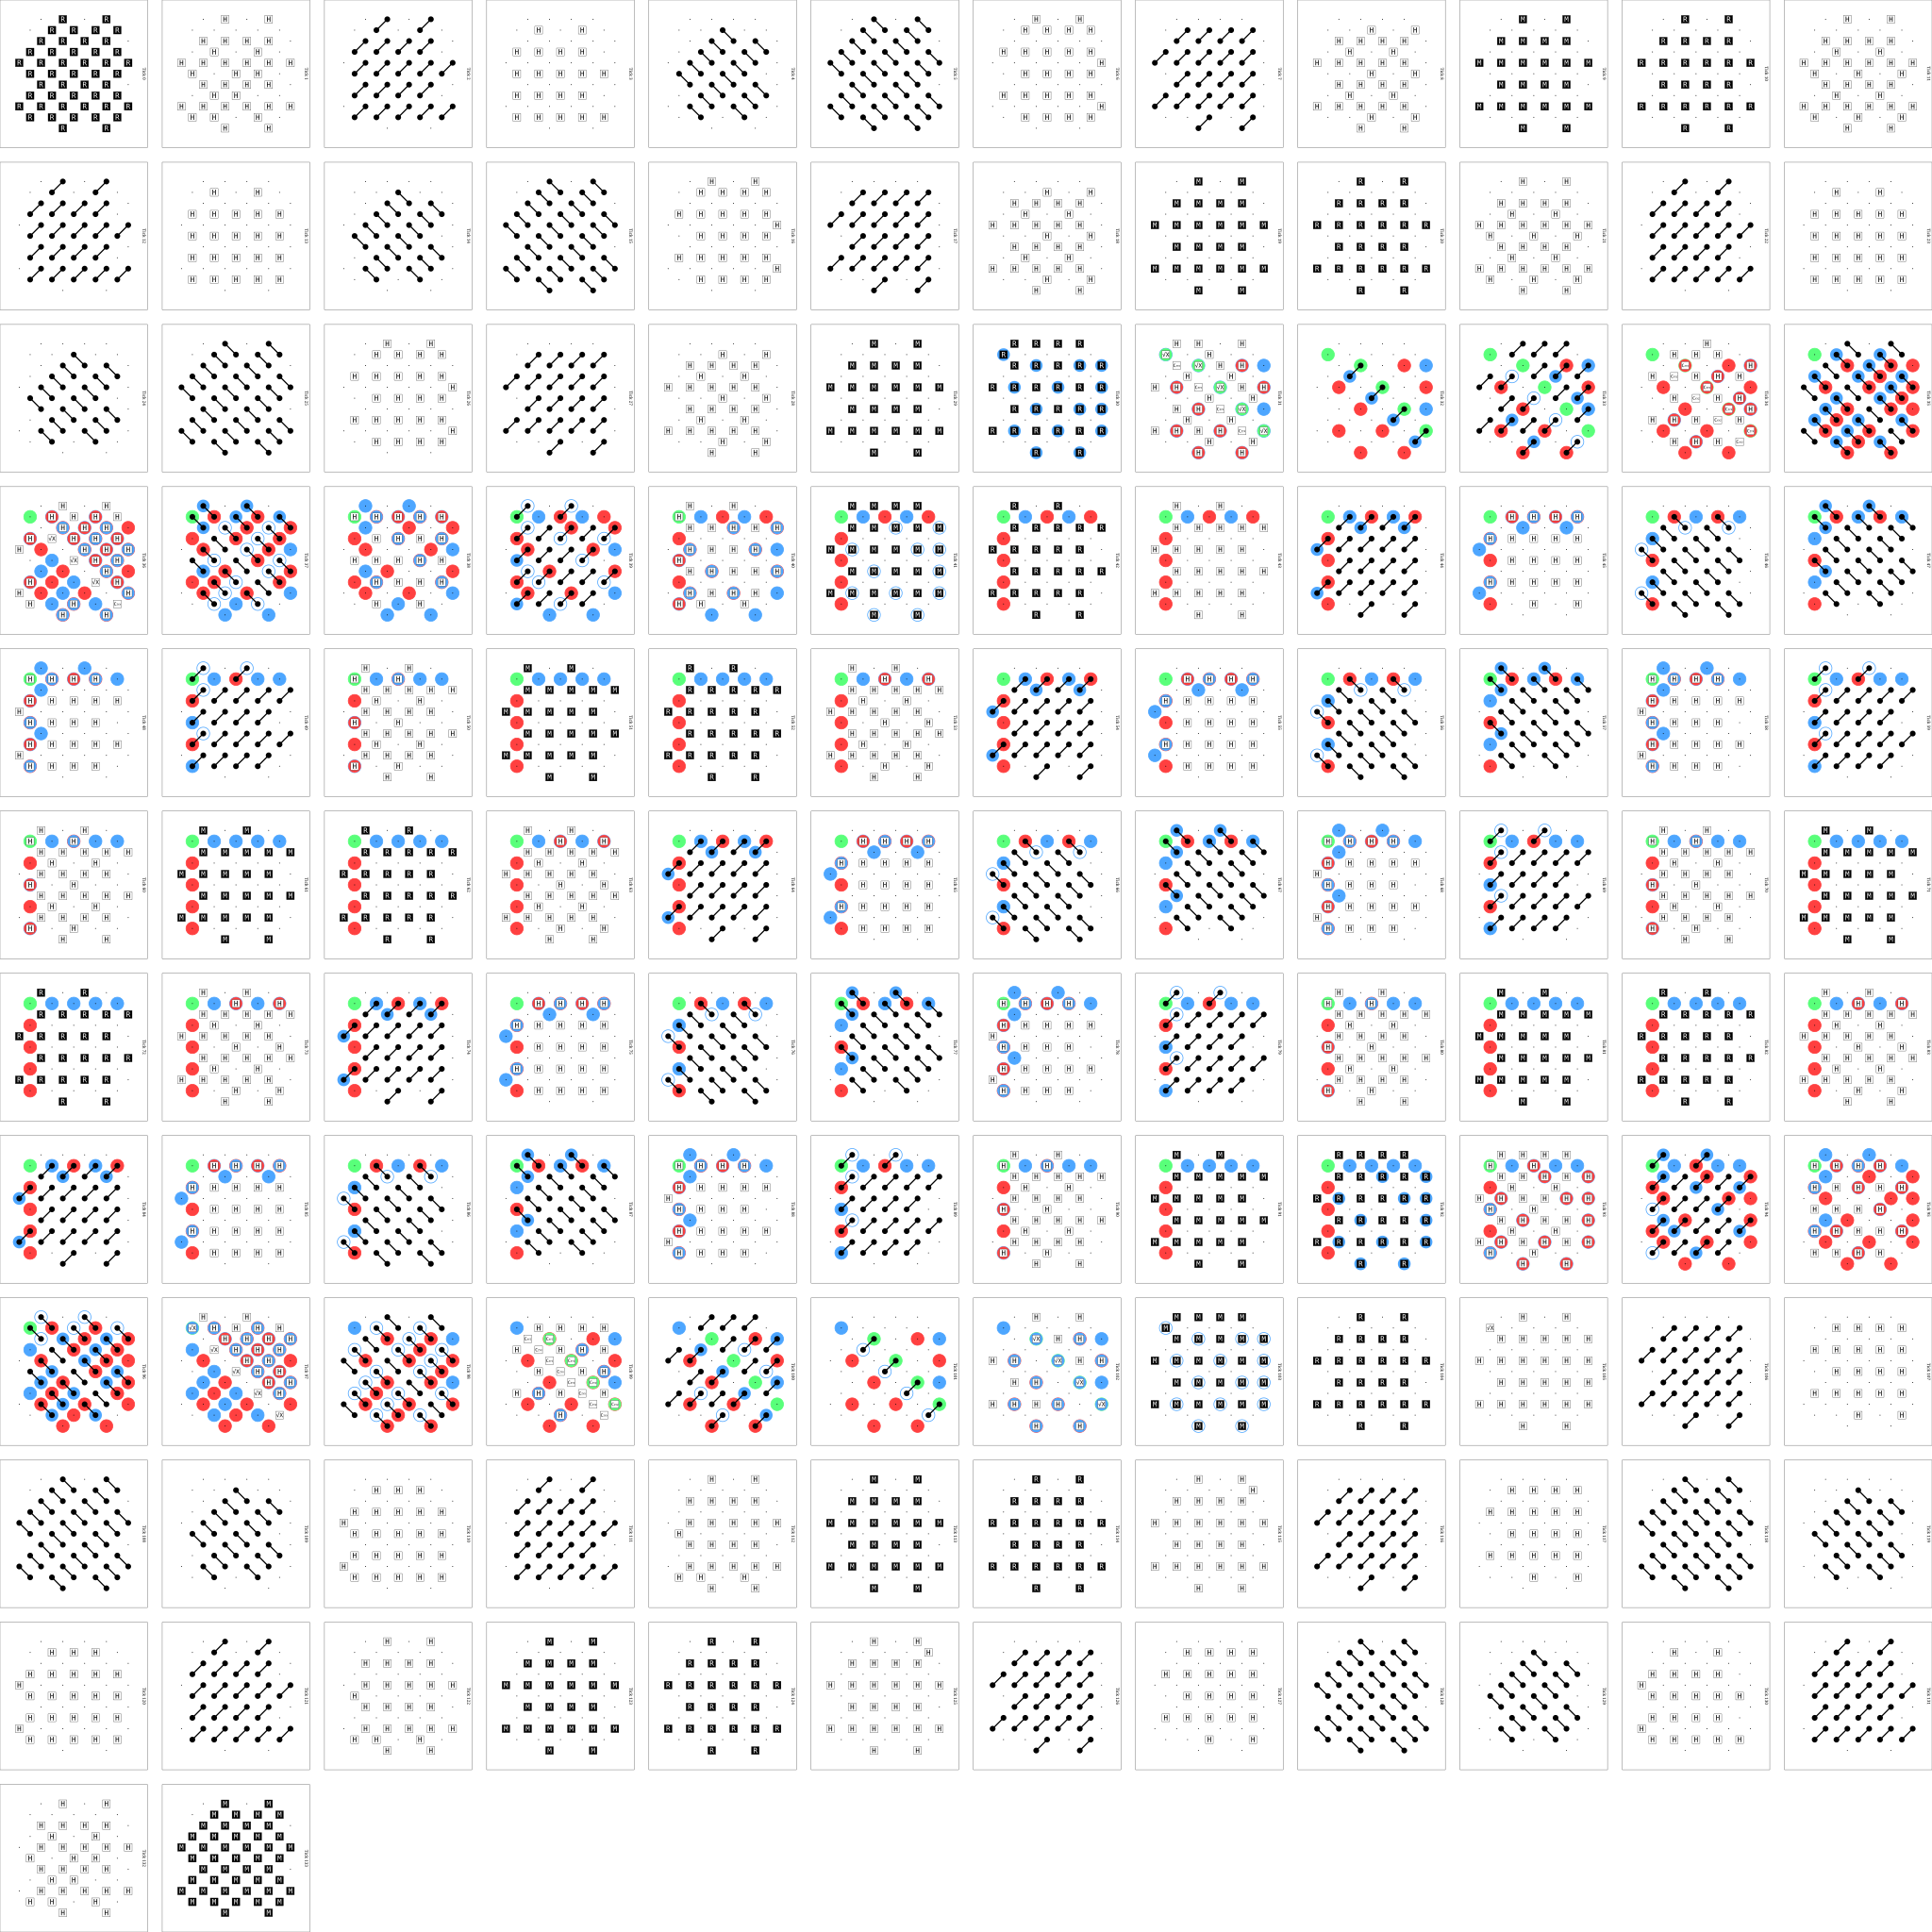

In [20]:
tt.diagram("detslice-with-ops-svg", filter_coords= ["L0"])

In [9]:
circuit = stim.Circuit('''
            R 1 3
            CX 0 1 2 3
           CX 4 3 2 1
            M 1 3
        ''')
circuit.solve_flow_measurements([
        stim.Flow("1 -> Z0*Z2"),
        stim.Flow("1 -> Z2*Z4"),
        stim.Flow("Z0*Z2 -> 1"),
        ])

[[0], [1], [0]]

In [24]:
tt2 = stim.Circuit("""QUBIT_COORDS(0, 0) 0
QUBIT_COORDS(0, 1) 1
QUBIT_COORDS(0, 2) 2
QUBIT_COORDS(0, 3) 3
QUBIT_COORDS(0, 4) 4
QUBIT_COORDS(1, 0) 5
QUBIT_COORDS(1, 1) 6
QUBIT_COORDS(1, 2) 7
QUBIT_COORDS(1, 3) 8
QUBIT_COORDS(1, 4) 9
QUBIT_COORDS(2, 0) 10
QUBIT_COORDS(2, 1) 11
QUBIT_COORDS(2, 2) 12
QUBIT_COORDS(2, 3) 13
QUBIT_COORDS(2, 4) 14
QUBIT_COORDS(3, 0) 15
QUBIT_COORDS(3, 1) 16
QUBIT_COORDS(3, 2) 17
QUBIT_COORDS(3, 3) 18
QUBIT_COORDS(3, 4) 19
QUBIT_COORDS(4, 0) 20
QUBIT_COORDS(4, 1) 21
QUBIT_COORDS(4, 2) 22
QUBIT_COORDS(4, 3) 23
QUBIT_COORDS(4, 4) 24
QUBIT_COORDS(-0.5, 1.5) 25
QUBIT_COORDS(-0.5, 3.5) 26
QUBIT_COORDS(0.5, -0.5) 27
QUBIT_COORDS(0.5, 0.5) 28
QUBIT_COORDS(0.5, 1.5) 29
QUBIT_COORDS(0.5, 2.5) 30
QUBIT_COORDS(0.5, 3.5) 31
QUBIT_COORDS(1.5, -0.5) 32
QUBIT_COORDS(1.5, 0.5) 33
QUBIT_COORDS(1.5, 1.5) 34
QUBIT_COORDS(1.5, 2.5) 35
QUBIT_COORDS(1.5, 3.5) 36
QUBIT_COORDS(1.5, 4.5) 37
QUBIT_COORDS(2.5, -0.5) 38
QUBIT_COORDS(2.5, 0.5) 39
QUBIT_COORDS(2.5, 1.5) 40
QUBIT_COORDS(2.5, 2.5) 41
QUBIT_COORDS(2.5, 3.5) 42
QUBIT_COORDS(3.5, -0.5) 43
QUBIT_COORDS(3.5, 0.5) 44
QUBIT_COORDS(3.5, 1.5) 45
QUBIT_COORDS(3.5, 2.5) 46
QUBIT_COORDS(3.5, 3.5) 47
QUBIT_COORDS(3.5, 4.5) 48
QUBIT_COORDS(4.5, 0.5) 49
QUBIT_COORDS(4.5, 1.5) 50
QUBIT_COORDS(4.5, 2.5) 51
QUBIT_COORDS(4.5, 3.5) 52
R 47 45 43 41 39 36 34 32 30 28 26 25 20 16 15 12 11 10 8 7 6 5 4 3 2 1 24 23 22 21 19 18 17 14 13 9 52 50 48 46 44 42 40 37 35 33 31 29
TICK
H 2 4 6 8 9 12 13 16 17 19 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
CX 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
H 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 22 24
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
CX 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
H 1 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 32 43 50 52
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
CX 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
H 6 8 10 12 14 16 18 20 22 24 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
M 47 45 43 41 39 36 34 32 30 28 26 25 52 50 48 46 44 42 40 37 35 33 31 29
DETECTOR(-0.5, 1.5, 0) rec[-13]
DETECTOR(-0.5, 3.5, 0) rec[-14]
DETECTOR(0.5, 0.5, 0) rec[-15]
DETECTOR(0.5, 2.5, 0) rec[-16]
DETECTOR(1.5, -0.5, 0) rec[-17]
DETECTOR(1.5, 1.5, 0) rec[-18]
DETECTOR(1.5, 4.5, 0) rec[-5]
DETECTOR(2.5, 0.5, 0) rec[-20]
DETECTOR(2.5, 3.5, 0) rec[-7]
DETECTOR(3.5, -0.5, 0) rec[-22]
DETECTOR(3.5, 2.5, 0) rec[-9]
DETECTOR(3.5, 4.5, 0) rec[-10]
DETECTOR(4.5, 1.5, 0) rec[-11]
DETECTOR(4.5, 3.5, 0) rec[-12]
SHIFT_COORDS(0, 0, 1)
TICK
REPEAT 2 {
R 47 45 43 41 39 36 34 32 30 28 26 25 52 50 48 46 44 42 40 37 35 33 31 29
TICK
H 2 4 6 8 12 14 16 18 22 24 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
CX 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
H 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 21 22 23 24
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
CX 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
H 1 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 32 43 50 52
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
CX 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
H 6 8 10 12 14 16 18 20 22 24 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
M 47 45 43 41 39 36 34 32 30 28 26 25 52 50 48 46 44 42 40 37 35 33 31 29
DETECTOR(-0.5, 1.5, 0) rec[-37] rec[-13]
DETECTOR(-0.5, 3.5, 0) rec[-38] rec[-14]
DETECTOR(0.5, 0.5, 0) rec[-39] rec[-15]
DETECTOR(0.5, 1.5, 0) rec[-25] rec[-1]
DETECTOR(0.5, 2.5, 0) rec[-40] rec[-16]
DETECTOR(0.5, 3.5, 0) rec[-26] rec[-2]
DETECTOR(1.5, -0.5, 0) rec[-41] rec[-17]
DETECTOR(1.5, 0.5, 0) rec[-27] rec[-3]
DETECTOR(1.5, 1.5, 0) rec[-42] rec[-18]
DETECTOR(1.5, 2.5, 0) rec[-28] rec[-4]
DETECTOR(1.5, 3.5, 0) rec[-43] rec[-19]
DETECTOR(1.5, 4.5, 0) rec[-29] rec[-5]
DETECTOR(2.5, 0.5, 0) rec[-44] rec[-20]
DETECTOR(2.5, 1.5, 0) rec[-30] rec[-6]
DETECTOR(2.5, 2.5, 0) rec[-45] rec[-21]
DETECTOR(2.5, 3.5, 0) rec[-31] rec[-7]
DETECTOR(3.5, -0.5, 0) rec[-46] rec[-22]
DETECTOR(3.5, 0.5, 0) rec[-32] rec[-8]
DETECTOR(3.5, 1.5, 0) rec[-47] rec[-23]
DETECTOR(3.5, 2.5, 0) rec[-33] rec[-9]
DETECTOR(3.5, 3.5, 0) rec[-48] rec[-24]
DETECTOR(3.5, 4.5, 0) rec[-34] rec[-10]
DETECTOR(4.5, 1.5, 0) rec[-35] rec[-11]
DETECTOR(4.5, 3.5, 0) rec[-36] rec[-12]
SHIFT_COORDS(0, 0, 1)
TICK
}
R 47 45 43 41 39 38 36 34 32 30 28 27 26 25 0 52 51 50 49 48 46 44 42 40 37 35 33 31 29
TICK
C_ZYX 28 34 41 47
H 6 8 10 12 14 16 18 22 24 25 26 27 29 30 31 32 35 36 37 39 42 43 44 45 48 50
SQRT_X 0 33 40 46 52
TICK
H 33 40 46 52
TICK
CX 6 33 12 40 18 46 24 52
TICK
H 33 40 46 52
TICK
H 25 26 32 29 30 31 38 39 35 36 37 43 44 45 42 49 50 51 48
TICK
CX 1 25 3 26 5 32 6 29 7 30 8 31 10 38 11 39 12 35 13 36 14 37 15 43 16 44 17 45 18 42 21 49 22 50 23 51 24 48
TICK
H 25 26 32 29 30 31 38 39 35 36 37 43 44 45 42 49 50 51 48
TICK
C_XYZ 6 12 18 24
C_ZYX 33 40 46 52
H 1 3 5 7 8 9 10 11 13 14 15 16 17 19 21 22 23 38 49 51
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
C_ZYX 24
H 1 3 4 5 10 11 14 15 16 17 20 21 22 23 25 26 32 33 37 39 40 43 44 45 46 48 50 52
SQRT_X 6 12 18
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
CX 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
H 0 2 5 6 7 8 9 10 11 12 13 15 16 17 18 19 20 21 22 23
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
CX 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
H 0 2 4 9 19 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
M 52 51 50 49 47 45 41 39 36 34 30 28 26 25 48 46 44 43 42 40 38 37 35 33 32 31 29 27
DETECTOR(-0.5, 1.5, 0) rec[-41] rec[-15]
DETECTOR(-0.5, 3.5, 0) rec[-42] rec[-16]
DETECTOR(0.5, 0.5, 0) rec[-43] rec[-17] rec[-1]
DETECTOR(0.5, 1.5, 0) rec[-29] rec[-2]
DETECTOR(0.5, 2.5, 0) rec[-44] rec[-18]
DETECTOR(0.5, 3.5, 0) rec[-30] rec[-3]
DETECTOR(1.5, -0.5, 0) rec[-45] rec[-4]
DETECTOR(1.5, 0.5, 0) rec[-31] rec[-21]
DETECTOR(1.5, 1.5, 0) rec[-46] rec[-19] rec[-5]
DETECTOR(1.5, 2.5, 0) rec[-32] rec[-6]
DETECTOR(1.5, 3.5, 0) rec[-47] rec[-20]
DETECTOR(1.5, 4.5, 0) rec[-33] rec[-7]
DETECTOR(2.5, 0.5, 0) rec[-48] rec[-8]
DETECTOR(2.5, 1.5, 0) rec[-34] rec[-23]
DETECTOR(2.5, 2.5, 0) rec[-49] rec[-22] rec[-9]
DETECTOR(2.5, 3.5, 0) rec[-35] rec[-10]
DETECTOR(3.5, -0.5, 0) rec[-50] rec[-11]
DETECTOR(3.5, 0.5, 0) rec[-36] rec[-25]
DETECTOR(3.5, 1.5, 0) rec[-51] rec[-12]
DETECTOR(3.5, 2.5, 0) rec[-37] rec[-27]
DETECTOR(3.5, 3.5, 0) rec[-52] rec[-24] rec[-13]
DETECTOR(3.5, 4.5, 0) rec[-38] rec[-14]
DETECTOR(4.5, 1.5, 0) rec[-39] rec[-26]
DETECTOR(4.5, 3.5, 0) rec[-40] rec[-28]
OBSERVABLE_INCLUDE(0) rec[-28] rec[-27] rec[-26] rec[-25] rec[-23] rec[-21] rec[-14] rec[-10] rec[-7] rec[-6] rec[-3] rec[-2]
SHIFT_COORDS(0, 0, 1)
TICK
R 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
TICK
H 25 26 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
CX 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
H 29 25 31 26 33 28 35 30 37 40 34 42 36 44 39 46 41 48 45 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 22 45 24 47
TICK
H 29 25 31 26 33 28 35 30 37 40 34 42 36 44 39 46 41 48 45 47
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
CX 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
H 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 23 25 26
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
CX 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
H 0 2 4 6 8 10 12 14 16 18 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
TICK
M 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
DETECTOR(-0.5, 1.5, 0) rec[-39] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-40] rec[-11]
DETECTOR(0.5, -0.5, 0) rec[-25] rec[-24]
DETECTOR(0.5, 0.5, 0) rec[-41] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-26] rec[-23]
DETECTOR(0.5, 2.5, 0) rec[-42] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-27] rec[-22]
DETECTOR(1.5, 0.5, 0) rec[-29] rec[-28] rec[-21]
DETECTOR(1.5, 1.5, 0) rec[-43] rec[-8]
DETECTOR(1.5, 2.5, 0) rec[-30] rec[-20]
DETECTOR(1.5, 3.5, 0) rec[-44] rec[-7]
DETECTOR(1.5, 4.5, 0) rec[-31] rec[-19]
DETECTOR(2.5, -0.5, 0) rec[-32] rec[-18]
DETECTOR(2.5, 0.5, 0) rec[-45] rec[-6]
DETECTOR(2.5, 1.5, 0) rec[-33] rec[-17]
DETECTOR(2.5, 2.5, 0) rec[-46] rec[-5]
DETECTOR(2.5, 3.5, 0) rec[-34] rec[-16]
DETECTOR(3.5, 0.5, 0) rec[-36] rec[-35] rec[-15]
DETECTOR(3.5, 1.5, 0) rec[-50] rec[-47] rec[-4]
DETECTOR(3.5, 2.5, 0) rec[-37] rec[-14]
DETECTOR(3.5, 3.5, 0) rec[-52] rec[-48] rec[-3]
DETECTOR(3.5, 4.5, 0) rec[-38] rec[-13]
DETECTOR(4.5, 0.5, 0) rec[-49] rec[-2]
DETECTOR(4.5, 2.5, 0) rec[-51] rec[-1]
SHIFT_COORDS(0, 0, 1)
TICK
REPEAT 4 {
R 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
TICK
H 6 8 10 12 14 16 18 20 22 24 25 26 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
CX 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
H 1 3 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
TICK
H 29 25 31 26 33 28 35 30 37 40 34 42 36 44 39 46 41 48 45 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 22 45 24 47
TICK
H 29 25 31 26 33 28 35 30 37 40 34 42 36 44 39 46 41 48 45 47
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
CX 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
H 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 23 25 26
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
CX 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
H 0 2 4 6 8 10 12 14 16 18 27 28 29 30 31 33 34 35 36 37 38 39 40 41 42 44 45 46 47 48 49 51
TICK
M 27 29 31 33 35 37 38 40 42 44 46 48 25 26 28 30 34 36 39 41 45 47 49 51
DETECTOR(-0.5, 1.5, 0) rec[-36] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-35] rec[-11]
DETECTOR(0.5, -0.5, 0) rec[-48] rec[-24]
DETECTOR(0.5, 0.5, 0) rec[-34] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-47] rec[-23]
DETECTOR(0.5, 2.5, 0) rec[-33] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-46] rec[-22]
DETECTOR(1.5, 0.5, 0) rec[-45] rec[-21]
DETECTOR(1.5, 1.5, 0) rec[-32] rec[-8]
DETECTOR(1.5, 2.5, 0) rec[-44] rec[-20]
DETECTOR(1.5, 3.5, 0) rec[-31] rec[-7]
DETECTOR(1.5, 4.5, 0) rec[-43] rec[-19]
DETECTOR(2.5, -0.5, 0) rec[-42] rec[-18]
DETECTOR(2.5, 0.5, 0) rec[-30] rec[-6]
DETECTOR(2.5, 1.5, 0) rec[-41] rec[-17]
DETECTOR(2.5, 2.5, 0) rec[-29] rec[-5]
DETECTOR(2.5, 3.5, 0) rec[-40] rec[-16]
DETECTOR(3.5, 0.5, 0) rec[-39] rec[-15]
DETECTOR(3.5, 1.5, 0) rec[-28] rec[-4]
DETECTOR(3.5, 2.5, 0) rec[-38] rec[-14]
DETECTOR(3.5, 3.5, 0) rec[-27] rec[-3]
DETECTOR(3.5, 4.5, 0) rec[-37] rec[-13]
DETECTOR(4.5, 0.5, 0) rec[-26] rec[-2]
DETECTOR(4.5, 2.5, 0) rec[-25] rec[-1]
SHIFT_COORDS(0, 0, 1)
TICK
}
R 27 29 31 32 33 35 37 38 40 42 43 44 46 48 25 26 28 30 34 36 39 41 45 47 49 50 51 52
TICK
H 0 2 4 6 8 10 12 14 16 18 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
CX 0 27 1 28 2 29 3 30 4 31 6 33 7 34 8 35 9 36 10 38 11 39 12 40 13 41 14 42 16 44 17 45 18 46 19 47 21 49 23 51
TICK
H 27 28 29 30 31 33 34 35 36 38 39 40 41 42 44 45 46 47 49 51
TICK
H 0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 23
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
CX 0 28 2 30 5 27 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 15 38 16 45 17 40 18 47 19 42 20 49 21 44 22 51 23 46
TICK
H 28 30 27 34 29 36 31 39 33 41 35 38 45 40 47 42 49 44 51 46
TICK
H 5 10 11 15 16 17 20 21 22 23 27 33 38 39 40 44 45 46 49 51
SQRT_X 0 6 12 18 24
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
C_XYZ 28 33 34 40 41 46 47 52
C_ZYX 6 12 18 24
H 1 3 5 7 8 10 11 13 14 15 16 17 20 21 22 23
TICK
H 25 26 32 29 30 31 38 39 35 36 37 43 44 45 42 49 50 51 48
TICK
CX 1 25 3 26 5 32 6 29 7 30 8 31 10 38 11 39 12 35 13 36 14 37 15 43 16 44 17 45 18 42 21 49 22 50 23 51 24 48
TICK
H 25 26 32 29 30 31 38 39 35 36 37 43 44 45 42 49 50 51 48
TICK
H 33 40 46 52
TICK
CX 6 33 12 40 18 46 24 52
TICK
H 33 40 46 52
TICK
H 25 26 29 30 31 32 35 36 37 39 42 43 44 45 48 50
SQRT_X 33 40 46 52
TICK
M 29 31 33 35 37 40 42 44 46 48 49 50 51 52 0 25 26 27 28 30 32 34 36 38 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-41] rec[-14]
DETECTOR(-0.5, 3.5, 0) rec[-40] rec[-13]
DETECTOR(0.5, -0.5, 0) rec[-53] rec[-12]
DETECTOR(0.5, 0.5, 0) rec[-39] rec[-27] rec[-11]
DETECTOR(0.5, 1.5, 0) rec[-52] rec[-29]
DETECTOR(0.5, 2.5, 0) rec[-38] rec[-10]
DETECTOR(0.5, 3.5, 0) rec[-51] rec[-28]
DETECTOR(1.5, 0.5, 0) rec[-50] rec[-9]
DETECTOR(1.5, 1.5, 0) rec[-37] rec[-24] rec[-8]
DETECTOR(1.5, 2.5, 0) rec[-49] rec[-26]
DETECTOR(1.5, 3.5, 0) rec[-36] rec[-7]
DETECTOR(1.5, 4.5, 0) rec[-48] rec[-25]
DETECTOR(2.5, -0.5, 0) rec[-47] rec[-6]
DETECTOR(2.5, 0.5, 0) rec[-35] rec[-22]
DETECTOR(2.5, 1.5, 0) rec[-46] rec[-5]
DETECTOR(2.5, 2.5, 0) rec[-34] rec[-21] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-45] rec[-23]
DETECTOR(3.5, 0.5, 0) rec[-44] rec[-3]
DETECTOR(3.5, 1.5, 0) rec[-33] rec[-18]
DETECTOR(3.5, 2.5, 0) rec[-43] rec[-2]
DETECTOR(3.5, 3.5, 0) rec[-32] rec[-16] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-42] rec[-20]
DETECTOR(4.5, 0.5, 0) rec[-31] rec[-19]
DETECTOR(4.5, 2.5, 0) rec[-30] rec[-17]
OBSERVABLE_INCLUDE(0) rec[-29] rec[-28] rec[-27] rec[-26] rec[-25] rec[-24] rec[-23] rec[-22] rec[-21] rec[-20] rec[-19] rec[-18] rec[-17] rec[-16] rec[-15]
SHIFT_COORDS(0, 0, 1)
TICK
R 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
TICK
H 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 49 50 51 52
SQRT_X 0
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
CX 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
CX 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
H 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
CX 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
H 2 4 9 19 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
M 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-38] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-37] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-51] rec[-39] rec[-36] rec[-35] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-53] rec[-24]
DETECTOR(0.5, 2.5, 0) rec[-34] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-52] rec[-23]
DETECTOR(1.5, -0.5, 0) rec[-33] rec[-30] rec[-8]
DETECTOR(1.5, 0.5, 0) rec[-51] rec[-22]
DETECTOR(1.5, 1.5, 0) rec[-51] rec[-48] rec[-32] rec[-7]
DETECTOR(1.5, 2.5, 0) rec[-50] rec[-21]
DETECTOR(1.5, 3.5, 0) rec[-31] rec[-6]
DETECTOR(1.5, 4.5, 0) rec[-49] rec[-20]
DETECTOR(2.5, 0.5, 0) rec[-29] rec[-5]
DETECTOR(2.5, 1.5, 0) rec[-48] rec[-19]
DETECTOR(2.5, 2.5, 0) rec[-48] rec[-45] rec[-28] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-47] rec[-18]
DETECTOR(3.5, -0.5, 0) rec[-27] rec[-3]
DETECTOR(3.5, 0.5, 0) rec[-46] rec[-17]
DETECTOR(3.5, 1.5, 0) rec[-26] rec[-2]
DETECTOR(3.5, 2.5, 0) rec[-45] rec[-16]
DETECTOR(3.5, 3.5, 0) rec[-45] rec[-40] rec[-25] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-44] rec[-15]
DETECTOR(4.5, 1.5, 0) rec[-43] rec[-42] rec[-14]
DETECTOR(4.5, 3.5, 0) rec[-41] rec[-40] rec[-13]
SHIFT_COORDS(0, 0, 1)
TICK
R 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
TICK
H 20 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
CX 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
CX 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
H 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 21 22 23 24 25 26
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
CX 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
H 2 4 9 19 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
M 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-36] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-35] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-34] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-48] rec[-24]
DETECTOR(0.5, 2.5, 0) rec[-33] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-47] rec[-23]
DETECTOR(1.5, -0.5, 0) rec[-32] rec[-8]
DETECTOR(1.5, 0.5, 0) rec[-46] rec[-22]
DETECTOR(1.5, 1.5, 0) rec[-31] rec[-7]
DETECTOR(1.5, 2.5, 0) rec[-45] rec[-21]
DETECTOR(1.5, 3.5, 0) rec[-30] rec[-6]
DETECTOR(1.5, 4.5, 0) rec[-44] rec[-20]
DETECTOR(2.5, 0.5, 0) rec[-29] rec[-5]
DETECTOR(2.5, 1.5, 0) rec[-43] rec[-19]
DETECTOR(2.5, 2.5, 0) rec[-28] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-42] rec[-18]
DETECTOR(3.5, -0.5, 0) rec[-27] rec[-3]
DETECTOR(3.5, 0.5, 0) rec[-41] rec[-17]
DETECTOR(3.5, 1.5, 0) rec[-26] rec[-2]
DETECTOR(3.5, 2.5, 0) rec[-40] rec[-16]
DETECTOR(3.5, 3.5, 0) rec[-25] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-39] rec[-15]
DETECTOR(4.5, 1.5, 0) rec[-38] rec[-14]
DETECTOR(4.5, 3.5, 0) rec[-37] rec[-13]
SHIFT_COORDS(0, 0, 1)
TICK
R 29 31 33 35 37 40 42 44 46 48 50 52 25 26 28 30 32 34 36 39 41 43 45 47
TICK
H 20 25 26 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
CX 1 25 3 26 5 28 6 29 7 30 8 31 10 33 11 34 12 35 13 36 14 37 15 39 16 40 17 41 18 42 20 44 21 45 22 46 23 47 24 48
TICK
H 25 26 28 29 30 31 33 34 35 36 37 39 40 41 42 44 45 46 47 48
TICK
H 1 3 5 6 7 8 10 11 12 13 14 15 16 17 18 20 21 22 23 24
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
CX 1 29 2 25 3 31 4 26 5 33 6 28 7 35 8 30 9 37 10 32 11 40 12 34 13 42 14 36 15 44 16 39 17 46 18 41 19 48 20 43 21 50 22 45 23 52 24 47
TICK
H 29 25 31 26 33 28 35 30 37 32 40 34 42 36 44 39 46 41 48 43 50 45 52 47
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
CX 2 30 6 34 7 29 8 36 9 31 10 39 11 33 12 41 13 35 16 45 17 40 18 47 19 42 21 44 23 46
TICK
H 30 34 29 36 31 39 33 41 35 45 40 47 42 44 46
TICK
H 1 2 3 4 5 6 7 8 9 11 12 13 14 15 16 17 18 19 22 24 25 26
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
CX 1 28 2 29 3 30 4 31 5 32 6 33 7 34 8 35 9 36 11 39 12 40 13 41 14 42 15 43 16 44 17 45 18 46 19 47 22 50 24 52
TICK
H 28 29 30 31 32 33 34 35 36 39 40 41 42 43 44 45 46 47 50 52
TICK
H 2 4 6 8 9 12 13 16 17 19 28 29 30 31 32 33 34 35 36 37 39 40 41 42 43 44 45 46 47 48 50 52
TICK
M 29 31 33 35 37 40 42 44 46 48 50 52 9 13 14 17 18 19 21 22 23 24 1 2 3 4 5 6 7 8 10 11 12 15 16 20 25 26 28 30 32 34 36 39 41 43 45 47
DETECTOR(-0.5, 1.5, 0) rec[-60] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-59] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-58] rec[-10]
DETECTOR(0.5, 1.5, 0) rec[-72] rec[-48]
DETECTOR(0.5, 2.5, 0) rec[-57] rec[-9]
DETECTOR(0.5, 3.5, 0) rec[-71] rec[-47]
DETECTOR(1.5, -0.5, 0) rec[-56] rec[-8]
DETECTOR(1.5, 0.5, 0) rec[-70] rec[-46]
DETECTOR(1.5, 1.5, 0) rec[-55] rec[-7]
DETECTOR(1.5, 2.5, 0) rec[-69] rec[-45]
DETECTOR(1.5, 3.5, 0) rec[-54] rec[-6]
DETECTOR(1.5, 4.5, 0) rec[-68] rec[-44]
DETECTOR(2.5, 0.5, 0) rec[-53] rec[-5]
DETECTOR(2.5, 1.5, 0) rec[-67] rec[-43]
DETECTOR(2.5, 2.5, 0) rec[-52] rec[-4]
DETECTOR(2.5, 3.5, 0) rec[-66] rec[-42]
DETECTOR(3.5, -0.5, 0) rec[-51] rec[-3]
DETECTOR(3.5, 0.5, 0) rec[-65] rec[-41]

DETECTOR(3.5, 1.5, 0) rec[-50] rec[-2]
DETECTOR(3.5, 2.5, 0) rec[-64] rec[-40]
DETECTOR(3.5, 3.5, 0) rec[-49] rec[-1]
DETECTOR(3.5, 4.5, 0) rec[-63] rec[-39]
DETECTOR(4.5, 1.5, 0) rec[-62] rec[-38]
DETECTOR(4.5, 3.5, 0) rec[-61] rec[-37]
DETECTOR(-0.5, 1.5, 0) rec[-26] rec[-25] rec[-12]
DETECTOR(-0.5, 3.5, 0) rec[-24] rec[-23] rec[-11]
DETECTOR(0.5, 0.5, 0) rec[-26] rec[-22] rec[-21] rec[-10]
DETECTOR(0.5, 2.5, 0) rec[-25] rec[-24] rec[-20] rec[-19] rec[-9]
DETECTOR(1.5, -0.5, 0) rec[-22] rec[-18] rec[-8]
DETECTOR(1.5, 1.5, 0) rec[-21] rec[-20] rec[-17] rec[-16] rec[-7]
DETECTOR(1.5, 4.5, 0) rec[-44] rec[-36] rec[-34]
DETECTOR(2.5, 0.5, 0) rec[-18] rec[-17] rec[-15] rec[-14] rec[-5]
DETECTOR(2.5, 3.5, 0) rec[-42] rec[-35] rec[-34] rec[-32] rec[-31]
DETECTOR(3.5, -0.5, 0) rec[-15] rec[-13] rec[-3]
DETECTOR(3.5, 2.5, 0) rec[-40] rec[-33] rec[-32] rec[-29] rec[-28]
DETECTOR(3.5, 4.5, 0) rec[-39] rec[-31] rec[-27]
DETECTOR(4.5, 1.5, 0) rec[-38] rec[-30] rec[-29]
DETECTOR(4.5, 3.5, 0) rec[-37] rec[-28] rec[-27]
SHIFT_COORDS(0, 0, 1)""")